# Case-Based Reasoning — Putusan Pidana Narkotika & Psikotropika
**Mata Kuliah:** Penalaran Komputer — Semester Genap 2025/2026  
**Program Studi:** Teknik Informatika, Universitas Muhammadiyah Malang  
**NIM:** 202310370311358  
**SubCPMK-3:** Implementasi siklus Case-Based Reasoning menggunakan dataset putusan Mahkamah Agung RI

---
### Siklus CBR yang diimplementasikan:
1. **Tahap 1** — Membangun Case Base (konversi PDF + preprocessing)
2. **Tahap 2** — Case Representation (ekstraksi metadata & fitur)
3. **Tahap 3** — Case Retrieval (TF-IDF + SVM + fungsi `retrieve()`)
4. **Tahap 4** — Solution Reuse (prediksi amar putusan)
5. **Tahap 5** — Model Evaluation (Accuracy, Precision, Recall, F1)

---
## ⚙️ Setup: Install Dependencies & Mount Google Drive

In [1]:
# Install semua library yang dibutuhkan
!pip install -q pdfminer.six nltk scikit-learn pandas matplotlib seaborn tqdm openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 27.3 MB/s eta 0:00:00


In [2]:
import os, re, time, json, pickle, logging, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
from pdfminer.high_level import extract_text as pdf_extract
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive berhasil di-mount.')

Mounted at /content/drive
✅ Google Drive berhasil di-mount.


In [6]:
# ================================================================
# KONFIGURASI PATH — Sesuaikan nama folder jika berbeda
# ================================================================
DRIVE_BASE    = Path('/content/drive/MyDrive/penalaran komputer/CBRR')

PDF_DIR       = DRIVE_BASE / 'data/raw/pdfs'
RAW_DIR       = DRIVE_BASE / 'data/raw'
PROCESSED_DIR = DRIVE_BASE / 'data/processed'
EVAL_DIR      = DRIVE_BASE / 'data/eval'
RESULTS_DIR   = DRIVE_BASE / 'data/results'
LOG_DIR       = DRIVE_BASE / 'logs'

# Buat semua folder jika belum ada
for d in [PDF_DIR, RAW_DIR, PROCESSED_DIR, EVAL_DIR, RESULTS_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Cek PDF tersedia
pdf_files = sorted(PDF_DIR.glob('*.pdf'))
print(f'📁 Base folder : {DRIVE_BASE}')
print(f'📄 PDF tersedia: {len(pdf_files)} file')
if len(pdf_files) < 30:
    print(f'⚠️  PERHATIAN: Butuh minimal 30 PDF. Baru ada {len(pdf_files)}.')
else:
    print('✅ Jumlah PDF mencukupi (≥30).')

📁 Base folder : /content/drive/MyDrive/penalaran komputer/CBRR
📄 PDF tersedia: 33 file
✅ Jumlah PDF mencukupi (≥30).


---
## 📁 Tahap 1: Membangun Case Base
**Tujuan:** Konversi PDF putusan → teks bersih, siap diproses model.

> PDF sudah diunduh manual dari [putusan3.mahkamahagung.go.id](https://putusan3.mahkamahagung.go.id) (Pidana Khusus → Narkotika)

### 1.1 Konversi PDF → Teks

In [7]:
def pdf_to_text(pdf_path):
    """Konversi satu file PDF ke string teks menggunakan pdfminer."""
    try:
        text = pdf_extract(str(pdf_path))
        return text if text and len(text.strip()) > 100 else None
    except Exception as e:
        return None

# Test konversi satu file
if pdf_files:
    sample = pdf_to_text(pdf_files[0])
    print(f'Contoh teks (100 karakter pertama):')
    print(sample[:200] if sample else 'GAGAL — coba file lain')
else:
    print('⚠️ Tidak ada PDF di folder. Pastikan sudah upload ke Google Drive.')

Contoh teks (100 karakter pertama):
Direktori Putusan Mahkamah Agung Republik Indonesia
putusan.mahkamahagung.go.id

Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Republik Indonesia
Mahkamah Agung Re


### 1.2 Fungsi Pembersihan Teks

In [8]:
def clean_text(text):
    """
    Bersihkan teks putusan MA:
    - Hapus header/footer, nomor halaman, watermark
    - Normalisasi spasi dan karakter
    """
    if not text:
        return ''

    # Hapus nomor halaman
    text = re.sub(r'-\s*\d+\s*-', '', text)
    text = re.sub(r'Hal\.?\s*\d+\s*(dari|of)\s*\d+', '', text, flags=re.IGNORECASE)

    # Hapus header/footer standar MA
    for pattern in [
        r'Disclaimer[^\n]*\n?',
        r'Kepaniteraan[^\n]*\n?',
        r'Mahkamah Agung Republik Indonesia[^\n]*\n?',
        r'putusan\.mahkamahagung\.go\.id',
        r'www\.mahkamahagung\.go\.id',
        r'DIREKTORI PUTUSAN[^\n]*\n?',
        r'\f',
    ]:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # Normalisasi whitespace
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

# Test
if pdf_files:
    raw = pdf_to_text(pdf_files[0])
    cleaned = clean_text(raw)
    print(f'Panjang teks asli  : {len(raw) if raw else 0} karakter')
    print(f'Panjang teks bersih: {len(cleaned)} karakter')
    print(f'Contoh:\n{cleaned[:300]}')

Panjang teks asli  : 57746 karakter
Panjang teks bersih: 46573 karakter
Contoh:
pelaksanaan fungsi peradilan. Namun dalam hal-hal tertentu masih dimungkinkan terjadi permasalahan teknis terkait dengan akurasi dan keterkinian informasi yang kami sajikan, hal mana akan terus kami perbaiki dari waktu kewaktu.
Dalam hal Anda menemukan inakurasi informasi yang termuat pada situs ini


### 1.3 Fungsi Validasi Teks

In [9]:
def validate_text(text, min_words=200):
    """
    Validasi teks: dianggap valid jika
    - Minimal min_words kata
    - Mengandung kata kunci putusan narkotika
    """
    if not text:
        return False, 0
    wc = len(text.split())
    keywords = ['putusan', 'terdakwa', 'dakwaan', 'mengadili', 'pasal', 'narkotika']
    has_kw = any(kw in text.lower() for kw in keywords)
    return wc >= min_words and has_kw, wc

print('✅ Fungsi validasi siap.')

✅ Fungsi validasi siap.


### 1.4 Pipeline Utama: Konversi Semua PDF

In [10]:
# Setup logging
logging.basicConfig(
    filename=str(LOG_DIR / 'cleaning.log'),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

saved, skipped = 0, 0
metadata_log = []

for i, pdf_path in enumerate(tqdm(pdf_files, desc='Konversi PDF')):
    # Konversi PDF → teks
    raw = pdf_to_text(pdf_path)
    if not raw:
        logging.warning(f'GAGAL konversi: {pdf_path.name}')
        skipped += 1
        continue

    # Bersihkan
    cleaned = clean_text(raw)

    # Validasi
    is_valid, wc = validate_text(cleaned)
    if not is_valid:
        logging.warning(f'SKIP (tidak valid): {pdf_path.name} | words={wc}')
        skipped += 1
        continue

    # Simpan sebagai .txt
    case_id = f'case_{saved+1:03d}'
    out_path = RAW_DIR / f'{case_id}.txt'
    out_path.write_text(cleaned, encoding='utf-8')

    metadata_log.append({
        'case_id'    : case_id,
        'file_asal'  : pdf_path.name,
        'word_count' : wc
    })
    logging.info(f'SAVED: {case_id} | words={wc} | {pdf_path.name}')
    saved += 1

print(f'\n=== Hasil Tahap 1 ===')
print(f'✅ Tersimpan : {saved} dokumen')
print(f'⚠️  Dilewati  : {skipped} dokumen')
print(f'📁 Lokasi    : {RAW_DIR}')

Konversi PDF: 100%|██████████| 33/33 [02:09<00:00,  3.93s/it]


=== Hasil Tahap 1 ===
✅ Tersimpan : 32 dokumen
⚠️  Dilewati  : 1 dokumen
📁 Lokasi    : /content/drive/MyDrive/penalaran komputer/CBRR/data/raw


### 1.5 Verifikasi Akhir Tahap 1

In [11]:
txt_files = sorted(RAW_DIR.glob('*.txt'))
print(f'Total file .txt di data/raw/: {len(txt_files)}')

assert len(txt_files) >= 30, f'❌ KURANG! Hanya {len(txt_files)}/30 dokumen'
print('✅ Jumlah dokumen mencukupi (≥30)')

df_log = pd.DataFrame(metadata_log)
if not df_log.empty:
    print(f"\nStatistik kata per dokumen:")
    print(f"  Rata-rata : {df_log['word_count'].mean():.0f} kata")
    print(f"  Minimum   : {df_log['word_count'].min()} kata")
    print(f"  Maximum   : {df_log['word_count'].max()} kata")
    df_log.to_csv(LOG_DIR / 'download_log.csv', index=False)
    display(df_log.head(5))

print('\n✅ Tahap 1 SELESAI')

Total file .txt di data/raw/: 32
✅ Jumlah dokumen mencukupi (≥30)

Statistik kata per dokumen:
  Rata-rata : 8767 kata
  Minimum   : 1978 kata
  Maximum   : 31179 kata


,case_id,file_asal,word_count
0,case_001,putusan_1048_pid.sus_2024_pn_tjk_2026060917514...,6158
1,case_002,putusan_1071_pid.sus_2024_pn_bdg_2026060917404...,8293
2,case_003,putusan_1173_pid.sus_2024_pn_tjk_2026060917413...,15670
3,case_004,putusan_1244_pid.sus_2024_pn_mks_2026060917534...,12785
4,case_005,putusan_1250_pid.sus_2024_pn_pbr_2026060917552...,10314



✅ Tahap 1 SELESAI


---
## 📊 Tahap 2: Case Representation
**Tujuan:** Ekstraksi metadata dan fitur teks dari setiap putusan → format terstruktur `.csv`

### 2.1 Fungsi Ekstraksi Metadata

In [19]:
def classify_verdict(amar_text):
    t = amar_text.lower()

    # Bebas
    if any(w in t for w in ['bebas', 'tidak terbukti', 'dibebaskan']):
        return 'bebas'

    # Cek pasal spesifik
    if 'pasal 112' in t: return 'bersalah_112'
    if 'pasal 114' in t: return 'bersalah_114'
    if 'pasal 127' in t: return 'bersalah_127'
    if 'pasal 111' in t: return 'bersalah_111'
    if 'pasal 132' in t: return 'bersalah_132'

    # Kalau amar tidak terdeteksi, cek dari teks lengkap
    if any(w in t for w in ['bersalah', 'terbukti', 'pidana penjara']):
        return 'bersalah_lain'

    return 'unknown'

In [30]:
def extract_amar(text):
    """Ekstrak amar putusan dari teks putusan MA."""
    pattern = r'(?:M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I|MENGADILI)(.{50,2000})(?:Demikianlah|Ditetapkan|Hakim Ketua|Hakim Anggota)'
    m = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if m:
        amar = re.sub(r'\s+', ' ', m.group(1).strip())
        return amar[:800]
    return 'UNKNOWN'

def classify_verdict(amar_text):
    """Klasifikasi amar putusan ke label kelas."""
    t = amar_text.lower()
    if any(w in t for w in ['bebas', 'tidak terbukti', 'dibebaskan']):
        return 'bebas'
    if 'pasal 112' in t: return 'bersalah_112'
    if 'pasal 114' in t: return 'bersalah_114'
    if 'pasal 127' in t: return 'bersalah_127'
    if 'pasal 111' in t: return 'bersalah_111'
    if 'pasal 132' in t: return 'bersalah_132'
    if any(w in t for w in ['bersalah', 'terbukti', 'pidana penjara']):
        return 'bersalah_lain'
    return 'unknown'

# Test langsung
sample = (RAW_DIR / 'case_001.txt').read_text(encoding='utf-8')
amar = extract_amar(sample)
label = classify_verdict(amar)
print(f'Amar  : {amar[:300]}')
print(f'Label : {label}')

Amar  : 1.Menyatakan Terdakwa I. Robbi Bin Jamal, dan Terdakwa II. Romani Bin SaidiAlm, terbukti secara sah dan meyakinkan bersalah melakukan tindak pidana“Tanpa hak atau melawan hukum, melakukan percobaan ataupermufakatan jahat memiliki, menyimpan, menguasai, ataumenyediakan Narkotika Golongan I dalam bent
Label : bersalah_lain


### 2.2 Fungsi Feature Engineering

In [20]:
STOPWORDS_ID = set(stopwords.words('indonesian'))

def extract_ringkasan(text, n=3):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return ' '.join(sentences[:n])[:600]

def clean_for_model(text):
    """Preprocessing teks untuk TF-IDF: lowercase, hapus punctuation & stopwords."""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in STOPWORDS_ID and len(t) > 2]
    return ' '.join(tokens)

print('✅ Fungsi feature engineering siap.')

✅ Fungsi feature engineering siap.


In [31]:
def classify_verdict(amar_text, full_text=''):
    """Klasifikasi berdasarkan amar + teks lengkap."""
    t = (amar_text + ' ' + full_text).lower()

    if any(w in t for w in ['bebas', 'tidak terbukti', 'dibebaskan']):
        return 'bebas'
    if 'pasal 112' in t: return 'bersalah_112'
    if 'pasal 114' in t: return 'bersalah_114'
    if 'pasal 127' in t: return 'bersalah_127'
    if 'pasal 111' in t: return 'bersalah_111'
    if 'pasal 132' in t: return 'bersalah_132'
    if any(w in t for w in ['bersalah', 'terbukti', 'pidana penjara']):
        return 'bersalah_lain'
    return 'unknown'

# Test
label = classify_verdict(amar, sample)
print(f'Label setelah fix: {label}')

Label setelah fix: bersalah_112


### 2.3 Proses Semua Dokumen

In [32]:
txt_files = sorted(RAW_DIR.glob('*.txt'))
records = []

for f in tqdm(txt_files, desc='Ekstraksi fitur'):
    text = f.read_text(encoding='utf-8')
    case_id = f.stem

    amar  = extract_amar(text)
    label = classify_verdict(amar, text)  # tambah parameter text
    records.append({
        'case_id'        : case_id,
        'no_perkara'     : extract_no_perkara(text),
        'tanggal'        : extract_tanggal(text),
        'jenis_perkara'  : 'Pidana Khusus Narkotika',
        'pasal'          : extract_pasal(text),
        'pihak'          : extract_pihak(text),
        'amar_putusan'   : amar,
        'label'          : label,
        'ringkasan_fakta': extract_ringkasan(text),
        'text_clean'     : clean_for_model(text),
        'text_full'      : text,
        'word_count'     : len(text.split()),
    })

df = pd.DataFrame(records)
print(f'\nTotal kasus diproses: {len(df)}')
print(f'\nDistribusi label:')
print(df['label'].value_counts().to_string())

Ekstraksi fitur: 100%|██████████| 32/32 [00:00<00:00, 36.58it/s]


Total kasus diproses: 32

Distribusi label:
label
bersalah_112    24
bebas            6
bersalah_114     2


### 2.4 Simpan ke CSV & JSON

In [34]:
# Simpan CSV
cols_csv = ['case_id','no_perkara','tanggal','jenis_perkara','pasal',
            'pihak','amar_putusan','label','ringkasan_fakta','word_count']
df[cols_csv].to_csv(PROCESSED_DIR / 'cases.csv', index=False, encoding='utf-8-sig')

# Simpan JSON
df.drop(columns=['text_full']).to_json(
    PROCESSED_DIR / 'cases.json', orient='records', force_ascii=False, indent=2
)

# Simpan versi clean untuk model
df[['case_id','label','text_clean']].to_csv(
    PROCESSED_DIR / 'cases_clean.csv', index=False, encoding='utf-8-sig'
)

print('✅ Saved: data/processed/cases.csv')
print('✅ Saved: data/processed/cases.json')
print('✅ Saved: data/processed/cases_clean.csv')
print()
display(df[cols_csv].head(3))
print('\n✅ Tahap 2 SELESAI')

✅ Saved: data/processed/cases.csv
✅ Saved: data/processed/cases.json
✅ Saved: data/processed/cases_clean.csv



,case_id,no_perkara,tanggal,jenis_perkara,pasal,pihak,amar_putusan,label,ringkasan_fakta,word_count
0,case_001,1048/Pid.Sus/2024/PN,01 Januari 1998,Pidana Khusus Narkotika,112; 132; 114; 187; 184 ayat (1),UNKNOWN,"1.Menyatakan Terdakwa I. Robbi Bin Jamal, dan ...",bersalah_112,pelaksanaan fungsi peradilan. Namun dalam hal-...,6158
1,case_002,1071/Pid.Sus/2024/PN,17 Maret 1994,Pidana Khusus Narkotika,112 ayat (1); 114; 112; 114 ayat (1); 6 ayat (1),KRISTIAWAN ABDUL KHOLID bin IWAN RUSKIWAN,: 1. Menyatakan terdakwa KRISTIAWAN ABDUL KHOL...,bebas,pelaksanaan fungsi peradilan. Namun dalam hal-...,8293
2,case_003,1173/Pid.Sus/2024/PN,3 Maret 1991,Pidana Khusus Narkotika,137; 84 ayat (2); 111; 112; 113,Elon DediHutabarat Bin Utama Razim Hutabarat y...,:1.Menyatakan Terdakwa Elon Dedi Hutabarat Bin...,bersalah_112,pelaksanaan fungsi peradilan. Namun dalam hal-...,15670



✅ Tahap 2 SELESAI


In [35]:
df = pd.read_csv(PROCESSED_DIR / 'cases.csv')
print(df['label'].value_counts())
print()
print("Contoh amar putusan case_001:")
print(df['amar_putusan'].iloc[0])

label
bersalah_112    24
bebas            6
bersalah_114     2
Name: count, dtype: int64

Contoh amar putusan case_001:
1.Menyatakan Terdakwa I. Robbi Bin Jamal, dan Terdakwa II. Romani Bin SaidiAlm, terbukti secara sah dan meyakinkan bersalah melakukan tindak pidana“Tanpa hak atau melawan hukum, melakukan percobaan ataupermufakatan jahat memiliki, menyimpan, menguasai, ataumenyediakan Narkotika Golongan I dalam bentuk bukan tanaman”sebagaimana dalam dakwaan alternatif Kedua Penuntut Umum;2.Menjatuhkan pidana terhadap Terdakwa I. Robbi Bin Jamal, dan Terdakwa II.Romani Bin Saidi Alm, oleh karena itu dengan pidana penjara masing masingselama 4 (empat) Tahun dan denda sejumlah Rp1.000.000.000,00 (satumiliar rupiah) dengan ketentuan apabila denda tersebut tidak dibayar makadiganti dengan pidana penjara masing masing selama 3 (Tiga) Bulan;3.Menetapkan masa penangkapan dan masa penahanan yang telah dijalanipara 


In [36]:
sample = (RAW_DIR / 'case_001.txt').read_text(encoding='utf-8')
print(sample[2000:4000])  # Tampilkan bagian tengah dokumen

 yang seharusnya ada, namun belum tersedia, maka harap segera hubungi Email : 
Halaman 2

2024/Reskrim dan Sp.Kap 53.a/VI/ /2024/Reskrim tanggal 25 Juni 2024 sampaidengan tanggal 28 Juni 2024;Terdakwa I. Robbi Bin Jama ditahan dalam Tahanan Rutan oleh: 1. Penyidik sejak tanggal 28 Juni 2024 sampai dengan tanggal 17 Juli 2024; 2. Penyidik Perpanjangan Oleh PU sejak tanggal 18 Juli 2024 sampai dengantanggal 26 Agustus 2024; 3. Penyidik Perpanjangan Pertama Oleh Ketua PN sejak tanggal 25 Agustus 2024sampai dengan tanggal 23 September 2024; 4. Penyidik Perpanjangan Kedua Oleh Ketua PN sejak tanggal 24 September 2024sampai dengan tanggal 23 Oktober 2024; 5. Penuntut sejak tanggal 23 Oktober 2024 sampai dengan tanggal 11 November2024; 6. Hakim PN sejak tanggal 07 November 2024 sampai dengan tanggal 06Desember 2024; 7. Hakim PN Perpanjangan Oleh Ketua PN sejak tanggal 07 Desember 2024sampai dengan tanggal 04 Februari 2025; Terdakwa II. Romani Bin Saidi Alm ditahan dalam Tahanan Rutan oleh: 1.

In [37]:
sample = (RAW_DIR / 'case_001.txt').read_text(encoding='utf-8')
print(sample[-3000:])  # Tampilkan 3000 karakter TERAKHIR

kwa dijatuhi pidana makaharuslah dibebani pula untuk membayar biaya perkara; Memperhatikan, Pasal 112 Ayat (1) UU RI No. 35 Tahun 2009 tentangNarkotika Jo Pasal 132 ayat (1) dan Undang-undang Nomor 8 Tahun 1981tentang Hukum Acara Pidana serta peraturan perundang-undangan lain yangbersangkutan;M E N G A D I L I1.Menyatakan Terdakwa I. Robbi Bin Jamal, dan Terdakwa II. Romani Bin SaidiAlm, terbukti secara sah dan meyakinkan bersalah melakukan tindak pidana“Tanpa hak atau melawan hukum, melakukan percobaan ataupermufakatan jahat memiliki, menyimpan, menguasai, ataumenyediakan Narkotika Golongan I dalam bentuk bukan tanaman”sebagaimana dalam dakwaan alternatif Kedua Penuntut Umum;2.Menjatuhkan pidana terhadap Terdakwa I. Robbi Bin Jamal, dan Terdakwa II.Romani Bin Saidi Alm, oleh karena itu dengan pidana penjara masing masingselama 4 (empat) Tahun dan denda sejumlah Rp1.000.000.000,00 (satumiliar rupiah) dengan ketentuan apabila denda tersebut tidak dibayar makadiganti dengan pidana penjar

---
## 🔍 Tahap 3: Case Retrieval
**Tujuan:** Membangun sistem retrieval **TF-IDF + SVM** untuk menemukan kasus paling mirip dengan query baru.

### 3.1 Load Data & TF-IDF Vectorizer

In [38]:
df_clean = pd.read_csv(PROCESSED_DIR / 'cases_clean.csv')
df_model = df_clean[df_clean['label'] != 'unknown'].copy()
print(f'Dataset untuk model: {len(df_model)} kasus')
print(f'Label: {df_model["label"].value_counts().to_dict()}')

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
X = tfidf.fit_transform(df_model['text_clean'].fillna(''))
print(f'\nShape matriks TF-IDF: {X.shape}')
print(f'Contoh fitur: {list(tfidf.get_feature_names_out()[:10])}')

Dataset untuk model: 32 kasus
Label: {'bersalah_112': 24, 'bebas': 6, 'bersalah_114': 2}

Shape matriks TF-IDF: (32, 5000)
Contoh fitur: ['abdul', 'abdul hamid', 'acara', 'acara pemeriksaan', 'acara penimbangan', 'acara persidangan', 'acara pidana', 'acarapemeriksaan', 'acarapemeriksaan laboratoris', 'acarapemeriksaan tingkat']


### 3.2 Splitting Data Train/Test (80:20)

In [39]:
le = LabelEncoder()
y = le.fit_transform(df_model['label'])
case_ids = df_model['case_id'].values

# Cek apakah bisa stratify
label_counts = pd.Series(y).value_counts()
can_stratify = all(label_counts >= 2)

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, case_ids,
    test_size=0.2,
    random_state=42,
    stratify=y if can_stratify else None
)

print(f'Train : {X_train.shape[0]} sampel')
print(f'Test  : {X_test.shape[0]} sampel')
print(f'Kelas : {list(le.classes_)}')

Train : 25 sampel
Test  : 7 sampel
Kelas : ['bebas', 'bersalah_112', 'bersalah_114']


### 3.3 Training SVM Classifier

In [40]:
svm = SVC(kernel='linear', probability=True, C=1.0, random_state=42)
svm.fit(X_train, y_train)

train_acc = svm.score(X_train, y_train)
test_acc  = svm.score(X_test,  y_test)
print(f'Train Accuracy : {train_acc:.4f}')
print(f'Test Accuracy  : {test_acc:.4f}')

Train Accuracy : 0.7600
Test Accuracy  : 0.7143


### 3.4 Fungsi Retrieval `retrieve(query, k=5)`

In [41]:
# Simpan semua vektor case base
X_all      = tfidf.transform(df_model['text_clean'].fillna(''))
all_ids    = df_model['case_id'].values
all_labels = df_model['label'].values

def preprocess_query(query):
    """Preprocessing query sama seperti pipeline training."""
    query = query.lower()
    query = re.sub(r'[^a-zA-Z\s]', ' ', query)
    return ' '.join([t for t in query.split() if t not in STOPWORDS_ID and len(t) > 2])

def retrieve(query: str, k: int = 5):
    """
    Fungsi retrieval utama CBR.
    1. Preprocessing query
    2. Hitung vektor TF-IDF query
    3. Hitung cosine similarity dengan semua case vectors
    4. Kembalikan top-k case_id

    Returns: list of (case_id, label, similarity_score)
    """
    q_clean = preprocess_query(query)
    q_vec   = tfidf.transform([q_clean])
    sims    = cosine_similarity(q_vec, X_all).flatten()
    top_k   = np.argsort(sims)[::-1][:k]
    return [(all_ids[i], all_labels[i], float(sims[i])) for i in top_k]

# Uji fungsi
print('Uji fungsi retrieve():')
test_query = 'terdakwa membawa sabu-sabu seberat 5 gram pasal 112 narkotika'
top5 = retrieve(test_query, k=5)
print(f'Query: "{test_query}"')
print()
for rank, (cid, lbl, score) in enumerate(top5, 1):
    print(f'  {rank}. {cid} | label={lbl} | similarity={score:.4f}')

Uji fungsi retrieve():
Query: "terdakwa membawa sabu-sabu seberat 5 gram pasal 112 narkotika"

  1. case_025 | label=bersalah_112 | similarity=0.1063
  2. case_015 | label=bersalah_112 | similarity=0.0921
  3. case_021 | label=bersalah_112 | similarity=0.0754
  4. case_026 | label=bersalah_112 | similarity=0.0738
  5. case_001 | label=bersalah_112 | similarity=0.0715


### 3.5 Buat File `queries.json` untuk Evaluasi

In [42]:
queries_eval = []
for i in range(min(10, len(ids_test))):
    row = df_model[df_model['case_id'] == ids_test[i]].iloc[0]
    queries_eval.append({
        'query_id'           : f'q{i+1:02d}',
        'query_text'         : row['text_clean'][:300],
        'ground_truth_id'    : row['case_id'],
        'ground_truth_label' : row['label'],
    })

with open(EVAL_DIR / 'queries.json', 'w', encoding='utf-8') as f:
    json.dump(queries_eval, f, ensure_ascii=False, indent=2)

print(f'✅ Saved: data/eval/queries.json ({len(queries_eval)} query)')
print()

# Uji setiap query
print('Hasil uji query:')
for q in queries_eval:
    results = retrieve(q['query_text'], k=5)
    top1_id = results[0][0]
    match = '✓ HIT ' if top1_id == q['ground_truth_id'] else '✗ MISS'
    print(f'  {match} | {q["query_id"]} | GT={q["ground_truth_id"]} | Top1={top1_id}')

✅ Saved: data/eval/queries.json (7 query)

Hasil uji query:
  ✓ HIT  | q01 | GT=case_032 | Top1=case_032
  ✗ MISS | q02 | GT=case_017 | Top1=case_022
  ✗ MISS | q03 | GT=case_015 | Top1=case_022
  ✗ MISS | q04 | GT=case_027 | Top1=case_022
  ✗ MISS | q05 | GT=case_008 | Top1=case_022
  ✓ HIT  | q06 | GT=case_025 | Top1=case_025
  ✗ MISS | q07 | GT=case_010 | Top1=case_022


### 3.6 Simpan Model

In [43]:
with open(PROCESSED_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open(PROCESSED_DIR / 'svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
with open(PROCESSED_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

np.save(PROCESSED_DIR / 'tfidf_matrix.npy', X_all.toarray())
pd.DataFrame({'case_id': all_ids, 'label': all_labels}).to_csv(
    PROCESSED_DIR / 'case_index.csv', index=False
)

print('✅ Model & indeks kasus tersimpan.')
print('\n✅ Tahap 3 SELESAI')

✅ Model & indeks kasus tersimpan.

✅ Tahap 3 SELESAI


---
## 🔄 Tahap 4: Case Solution Reuse
**Tujuan:** Gunakan top-k kasus termirip sebagai dasar prediksi amar putusan kasus baru.

### 4.1 Load Data Solusi

In [44]:
df_cases = pd.read_csv(PROCESSED_DIR / 'cases.csv')
df_index = pd.read_csv(PROCESSED_DIR / 'case_index.csv')

case_solutions = dict(zip(df_cases['case_id'], df_cases['amar_putusan']))
case_labels    = dict(zip(df_index['case_id'], df_index['label']))
print(f'✅ Case base dimuat: {len(case_labels)} kasus')

✅ Case base dimuat: 32 kasus


### 4.2 Fungsi Ekstrak & Prediksi Solusi

In [45]:
def get_top_k_solutions(query: str, k: int = 5):
    """Ambil amar putusan dari top-k kasus termirip."""
    top_k = retrieve(query, k=k)
    return [{
        'case_id': cid,
        'score'  : score,
        'label'  : lbl,
        'amar'   : case_solutions.get(cid, 'UNKNOWN'),
    } for cid, lbl, score in top_k]

def majority_vote(solutions):
    """Pilih label yang paling banyak muncul (majority vote)."""
    labels = [s['label'] for s in solutions if s['label'] != 'unknown']
    return Counter(labels).most_common(1)[0][0] if labels else 'unknown'

def weighted_similarity(solutions):
    """Pilih label dengan total skor similarity terbesar."""
    weights = {}
    for s in solutions:
        if s['label'] != 'unknown':
            weights[s['label']] = weights.get(s['label'], 0) + s['score']
    return max(weights, key=weights.get) if weights else 'unknown'

def predict_outcome(query: str, k: int = 5, method: str = 'weighted') -> dict:
    """
    Prediksi amar putusan untuk kasus baru.

    Args:
        query  : Teks deskripsi kasus baru
        k      : Jumlah kasus terdekat yang digunakan
        method : 'majority' atau 'weighted'

    Returns:
        dict berisi predicted_label, predicted_solution, top_k_cases
    """
    solutions = get_top_k_solutions(query, k=k)

    pred_label = weighted_similarity(solutions) if method == 'weighted' else majority_vote(solutions)

    matching = [s for s in solutions if s['label'] == pred_label]
    pred_solution = matching[0]['amar'] if matching else solutions[0]['amar']

    return {
        'predicted_label'   : pred_label,
        'predicted_solution': pred_solution,
        'top_k_cases'       : [s['case_id'] for s in solutions],
        'top_k_scores'      : [round(s['score'], 4) for s in solutions],
    }

print('✅ Fungsi prediksi solusi siap.')

✅ Fungsi prediksi solusi siap.


### 4.3 Demo Manual: 5 Kasus Baru

In [46]:
demo_queries = [
    {'query_id': 'demo_1', 'query': 'terdakwa tertangkap tangan membawa 10 gram sabu jenis metamfetamina'},
    {'query_id': 'demo_2', 'query': 'terdakwa menjual dan mengedarkan narkotika golongan 1 kepada beberapa orang'},
    {'query_id': 'demo_3', 'query': 'terdakwa menggunakan narkotika untuk diri sendiri sesuai keterangan saksi'},
    {'query_id': 'demo_4', 'query': 'terdakwa memiliki dan menyimpan ganja seberat 50 gram dalam rumahnya'},
    {'query_id': 'demo_5', 'query': 'terdakwa tidak terbukti terlibat peredaran narkoba berdasarkan bukti'},
]

print('=== Demo Prediksi 5 Kasus Baru ===\n')
for q in demo_queries:
    res = predict_outcome(q['query'])
    print(f"Query ID   : {q['query_id']}")
    print(f"Deskripsi  : {q['query']}")
    print(f"Prediksi   : {res['predicted_label']}")
    print(f"Top-5 Kasus: {res['top_k_cases']}")
    print(f"Solusi     : {res['predicted_solution'][:150]}...")
    print('-' * 70)

=== Demo Prediksi 5 Kasus Baru ===

Query ID   : demo_1
Deskripsi  : terdakwa tertangkap tangan membawa 10 gram sabu jenis metamfetamina
Prediksi   : bersalah_112
Top-5 Kasus: ['case_021', 'case_029', 'case_011', 'case_014', 'case_032']
Solusi     : UNKNOWN...
----------------------------------------------------------------------
Query ID   : demo_2
Deskripsi  : terdakwa menjual dan mengedarkan narkotika golongan 1 kepada beberapa orang
Prediksi   : bersalah_112
Top-5 Kasus: ['case_029', 'case_009', 'case_019', 'case_018', 'case_016']
Solusi     : :1.Menyatakan terdakwa Mhd. Syahrul Savawi alias Dodi tersebut di atas, terbuktisecara sah dan meyakinkan bersalah melakukan tindak pidana permufakata...
----------------------------------------------------------------------
Query ID   : demo_3
Deskripsi  : terdakwa menggunakan narkotika untuk diri sendiri sesuai keterangan saksi
Prediksi   : bersalah_112
Top-5 Kasus: ['case_031', 'case_032', 'case_007', 'case_029', 'case_010']
Solusi     : :

### 4.4 Simpan Hasil Prediksi

In [47]:
with open(EVAL_DIR / 'queries.json', encoding='utf-8') as f:
    eval_queries = json.load(f)

eval_preds = []
for q in eval_queries:
    res = predict_outcome(q['query_text'])
    eval_preds.append({
        'query_id'          : q['query_id'],
        'ground_truth_label': q['ground_truth_label'],
        'predicted_label'   : res['predicted_label'],
        'predicted_solution': res['predicted_solution'][:300],
        'top_5_case_ids'    : ', '.join(res['top_k_cases']),
    })

df_pred = pd.DataFrame(eval_preds)
df_pred.to_csv(RESULTS_DIR / 'predictions.csv', index=False, encoding='utf-8-sig')
print('✅ Saved: data/results/predictions.csv')
display(df_pred)
print('\n✅ Tahap 4 SELESAI')

✅ Saved: data/results/predictions.csv


,query_id,ground_truth_label,predicted_label,predicted_solution,top_5_case_ids
0,q01,bersalah_112,bersalah_112,:1.Menyatakan Terdakwa DONNY ALS DONKRAY terse...,"case_032, case_029, case_022, case_020, case_016"
1,q02,bebas,bersalah_112,:1.Menerima permintaan banding dari Penuntut U...,"case_022, case_020, case_016, case_015, case_031"
2,q03,bersalah_112,bersalah_112,:1.Menerima permintaan banding dari Penuntut U...,"case_022, case_020, case_016, case_015, case_012"
3,q04,bersalah_112,bersalah_112,:1.Menerima permintaan banding dari Penuntut U...,"case_022, case_020, case_016, case_015, case_027"
4,q05,bersalah_112,bersalah_112,:1.Menerima permintaan banding dari Penuntut U...,"case_022, case_020, case_016, case_015, case_012"
5,q06,bersalah_112,bersalah_112,:1.Menyatakan Terdakwa Akhmad A Bin Abas terse...,"case_025, case_022, case_028, case_020, case_016"
6,q07,bersalah_114,bersalah_112,:1.Menerima permintaan banding dari Penuntut U...,"case_022, case_020, case_016, case_015, case_012"



✅ Tahap 4 SELESAI


---
## 📈 Tahap 5: Model Evaluation
**Tujuan:** Ukur performa retrieval & prediksi menggunakan Accuracy, Precision, Recall, F1-score.

### 5.1 Evaluasi Hit Rate Retrieval (Top-k)

In [48]:
with open(EVAL_DIR / 'queries.json', encoding='utf-8') as f:
    eval_queries = json.load(f)

results_retrieval = []
for k_val in [1, 3, 5]:
    hits = 0
    for q in eval_queries:
        top_k = retrieve(q['query_text'], k=k_val)
        if q['ground_truth_id'] in [r[0] for r in top_k]:
            hits += 1
    hit_rate = hits / len(eval_queries) if eval_queries else 0
    results_retrieval.append({'k': k_val, 'hit_rate': hit_rate, 'hits': hits, 'total': len(eval_queries)})
    print(f'Hit@{k_val}: {hit_rate:.4f}  ({hits}/{len(eval_queries)})')

Hit@1: 0.2857  (2/7)
Hit@3: 0.2857  (2/7)
Hit@5: 0.5714  (4/7)


### 5.2 Evaluasi Klasifikasi SVM

In [49]:
# Re-split data test
X_full = tfidf.transform(df_model['text_clean'].fillna(''))
y_full = le.transform(df_model['label'])

_, X_test_eval, _, y_test_eval = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42,
    stratify=y_full if all(pd.Series(y_full).value_counts() >= 2) else None
)

y_pred_svm = svm.predict(X_test_eval)

acc  = accuracy_score(y_test_eval, y_pred_svm)
prec = precision_score(y_test_eval, y_pred_svm, average='weighted', zero_division=0)
rec  = recall_score(y_test_eval, y_pred_svm, average='weighted', zero_division=0)
f1   = f1_score(y_test_eval, y_pred_svm, average='weighted', zero_division=0)

print('=== Evaluasi SVM — Test Set ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')
print()
print(classification_report(y_test_eval, y_pred_svm, target_names=le.classes_, zero_division=0))

=== Evaluasi SVM — Test Set ===
Accuracy  : 0.7143
Precision : 0.5102
Recall    : 0.7143
F1-Score  : 0.5952

              precision    recall  f1-score   support

       bebas       0.00      0.00      0.00         1
bersalah_112       0.71      1.00      0.83         5
bersalah_114       0.00      0.00      0.00         1

    accuracy                           0.71         7
   macro avg       0.24      0.33      0.28         7
weighted avg       0.51      0.71      0.60         7



### 5.3 Evaluasi Prediksi Solusi

In [50]:
df_pred = pd.read_csv(RESULTS_DIR / 'predictions.csv')
valid = df_pred[
    (df_pred['ground_truth_label'] != 'unknown') &
    (df_pred['predicted_label'] != 'unknown')
].dropna(subset=['ground_truth_label', 'predicted_label'])

if not valid.empty:
    y_true = valid['ground_truth_label']
    y_pred_val = valid['predicted_label']
    pred_acc  = accuracy_score(y_true, y_pred_val)
    pred_prec = precision_score(y_true, y_pred_val, average='weighted', zero_division=0)
    pred_rec  = recall_score(y_true, y_pred_val, average='weighted', zero_division=0)
    pred_f1   = f1_score(y_true, y_pred_val, average='weighted', zero_division=0)

    print('=== Evaluasi Prediksi Solusi ===')
    print(f'Accuracy  : {pred_acc:.4f}')
    print(f'Precision : {pred_prec:.4f}')
    print(f'Recall    : {pred_rec:.4f}')
    print(f'F1-Score  : {pred_f1:.4f}')
else:
    print('⚠️ Data prediksi tidak cukup untuk evaluasi.')
    pred_acc = pred_prec = pred_rec = pred_f1 = 0.0

=== Evaluasi Prediksi Solusi ===
Accuracy  : 0.7143
Precision : 0.5102
Recall    : 0.7143
F1-Score  : 0.5952


### 5.4 Visualisasi: Bar Chart & Confusion Matrix

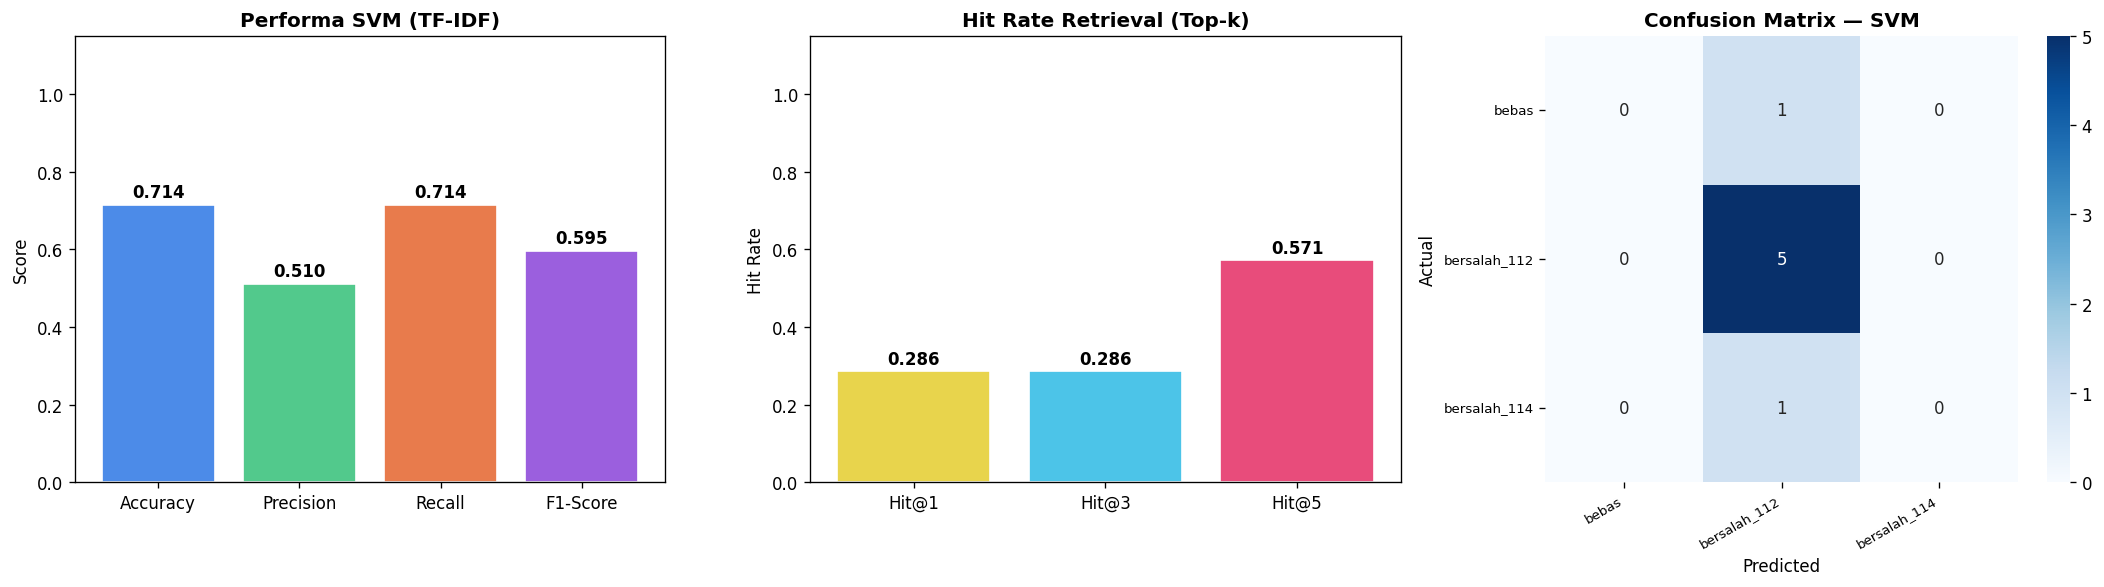

✅ Saved: data/eval/performance_chart.png


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Performa SVM ---
metrics_svm = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
ax1 = axes[0]
bars = ax1.bar(metrics_svm.keys(), metrics_svm.values(),
               color=['#4C8BE8','#52C98C','#E87B4C','#9B5FDE'], edgecolor='white')
ax1.set_title('Performa SVM (TF-IDF)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
for bar, val in zip(bars, metrics_svm.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# --- Plot 2: Hit Rate ---
ax2 = axes[1]
bars2 = ax2.bar([f'Hit@{r["k"]}' for r in results_retrieval],
                [r['hit_rate'] for r in results_retrieval],
                color=['#E8D44C','#4CC4E8','#E84C7B'], edgecolor='white')
ax2.set_title('Hit Rate Retrieval (Top-k)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.15)
ax2.set_ylabel('Hit Rate')
for bar, r in zip(bars2, results_retrieval):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{r['hit_rate']:.3f}", ha='center', fontsize=10, fontweight='bold')

# --- Plot 3: Confusion Matrix ---
ax3 = axes[2]
cm = confusion_matrix(y_test_eval, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax3.set_title('Confusion Matrix — SVM', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.setp(ax3.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(EVAL_DIR / 'performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: data/eval/performance_chart.png')

### 5.5 Analisis Kegagalan (Error Analysis)

In [52]:
df_pred = pd.read_csv(RESULTS_DIR / 'predictions.csv')
df_errors = df_pred[
    (df_pred['ground_truth_label'] != 'unknown') &
    (df_pred['predicted_label'] != 'unknown') &
    (df_pred['ground_truth_label'] != df_pred['predicted_label'])
]

print(f'Kasus gagal diprediksi: {len(df_errors)} dari {len(df_pred)}')

if not df_errors.empty:
    display(df_errors[['query_id','ground_truth_label','predicted_label','top_5_case_ids']])

print("""
Analisis Penyebab Kegagalan:
1. Kata kunci pasal yang overlap antar kelas (misal Pasal 112 dan 114 sama-sama menyebut kepemilikan)
2. Distribusi kelas tidak seimbang (kelas minoritas kurang terwakili)
3. Query terlalu pendek → vektor TF-IDF kurang representatif

Rekomendasi Perbaikan:
- Tambah volume data (>50 dokumen) terutama kelas minoritas
- Tuning hyperparameter SVM (C, kernel='rbf')
- Coba IndoBERT embedding untuk representasi semantik lebih kaya
- Gunakan SMOTE untuk oversampling kelas minoritas
""")

Kasus gagal diprediksi: 2 dari 7


,query_id,ground_truth_label,predicted_label,top_5_case_ids
1,q02,bebas,bersalah_112,"case_022, case_020, case_016, case_015, case_031"
6,q07,bersalah_114,bersalah_112,"case_022, case_020, case_016, case_015, case_012"



Analisis Penyebab Kegagalan:
1. Kata kunci pasal yang overlap antar kelas (misal Pasal 112 dan 114 sama-sama menyebut kepemilikan)
2. Distribusi kelas tidak seimbang (kelas minoritas kurang terwakili)
3. Query terlalu pendek → vektor TF-IDF kurang representatif

Rekomendasi Perbaikan:
- Tambah volume data (>50 dokumen) terutama kelas minoritas
- Tuning hyperparameter SVM (C, kernel='rbf')
- Coba IndoBERT embedding untuk representasi semantik lebih kaya
- Gunakan SMOTE untuk oversampling kelas minoritas



### 5.6 Simpan Metrics ke CSV

In [54]:
df_retrieval_metrics = pd.DataFrame([
    {'model': 'TF-IDF + SVM', 'k': r['k'],  'metric': 'Hit Rate',  'value': r['hit_rate']}
    for r in results_retrieval
] + [
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'Accuracy',  'value': acc},
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'Precision', 'value': prec},
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'Recall',    'value': rec},
    {'model': 'TF-IDF + SVM', 'k': '-', 'metric': 'F1-Score',  'value': f1},
])
df_retrieval_metrics.to_csv(EVAL_DIR / 'retrieval_metrics.csv', index=False)

df_prediction_metrics = pd.DataFrame([{
    'accuracy': pred_acc, 'precision': pred_prec,
    'recall': pred_rec,   'f1': pred_f1
}])
df_prediction_metrics.to_csv(EVAL_DIR / 'prediction_metrics.csv', index=False)

print('✅ Saved: data/eval/retrieval_metrics.csv')
print('✅ Saved: data/eval/prediction_metrics.csv')
display(df_retrieval_metrics)


✅ Saved: data/eval/retrieval_metrics.csv
✅ Saved: data/eval/prediction_metrics.csv


,model,k,metric,value
0,TF-IDF + SVM,1,Hit Rate,0.285714
1,TF-IDF + SVM,3,Hit Rate,0.285714
2,TF-IDF + SVM,5,Hit Rate,0.571429
3,TF-IDF + SVM,-,Accuracy,0.714286
4,TF-IDF + SVM,-,Precision,0.510204
5,TF-IDF + SVM,-,Recall,0.714286
6,TF-IDF + SVM,-,F1-Score,0.595238
